In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers.experimental import AdamW

In [4]:
# Define paths and parameters
DATASET_DIR = '/content/drive/MyDrive/Mango_Leaf_Dataset'  # Replace with the path to your dataset
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.01

In [5]:
# Create ImageDataGenerators for data augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 20% of data will be used for validation
)

In [6]:
# Load training and validation data
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',  # Use 'sparse' for single integer labels
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)


Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


In [7]:
# Define the CNN model
model = Sequential([
    tf.keras.layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(5, activation='softmax')  # Assuming 5 classes in your dataset
])


In [8]:
# Define the optimizer with weight decay
optimizer = AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Compile the model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [9]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/20
63/63 [==============================] - 782s 12s/step - loss: 1.6091 - accuracy: 0.3105 - val_loss: 1.3737 - val_accuracy: 0.3740
Epoch 2/20
63/63 [==============================] - 47s 754ms/step - loss: 0.7755 - accuracy: 0.6855 - val_loss: 0.9283 - val_accuracy: 0.5360
Epoch 3/20
63/63 [==============================] - 45s 717ms/step - loss: 0.5556 - accuracy: 0.7870 - val_loss: 0.8102 - val_accuracy: 0.5380
Epoch 4/20
63/63 [==============================] - 46s 739ms/step - loss: 0.4353 - accuracy: 0.8390 - val_loss: 0.7457 - val_accuracy: 0.6900
Epoch 5/20
63/63 [==============================] - 45s 718ms/step - loss: 0.3631 - accuracy: 0.8725 - val_loss: 0.5734 - val_accuracy: 0.7600
Epoch 6/20
63/63 [==============================] - 46s 737ms/step - loss: 0.3092 - accuracy: 0.8960 - val_loss: 0.4056 - val_accuracy: 0.8800
Epoch 7/20
63/63 [==============================] - 46s 723ms/step - loss: 0.2636 - accuracy: 0.9135 - val_loss: 0.4827 - val_accuracy: 0.8260


In [10]:
model.save('model5.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [11]:
# Evaluation Metrics
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Training Accuracy: 0.9810000061988831
Validation Accuracy: 0.9599999785423279


In [13]:
class_indices = train_generator.class_indices

print("Class labels and their assigned values:")
for class_name, class_value in class_indices.items():
    print(f"{class_name}: {class_value}")

Class labels and their assigned values:
Anthracnose: 0
Cutting Weevil: 1
Die Back: 2
Healthy: 3
Powdery Mildew: 4


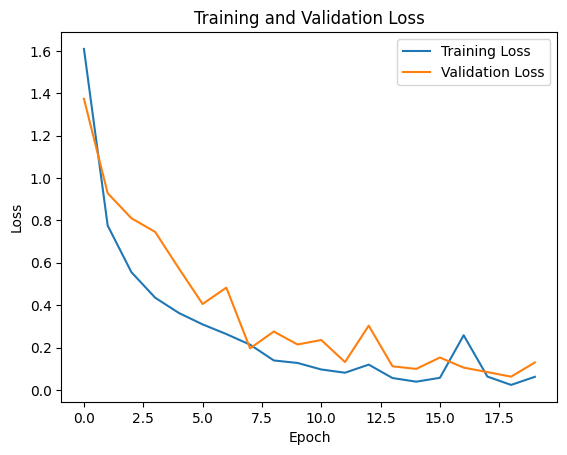

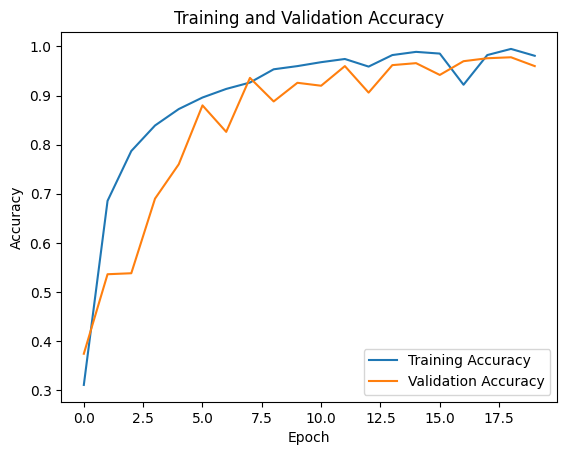

In [12]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()